# 📌 Challenge Pembuatan Chatbot Berbasis BERT

## Deskripsi Tugas
Pada challenge ini, setiap mahasiswa diminta untuk membuat sebuah chatbot menggunakan model **BERT**, silahkan untuk menggunakan search engine, gpt, gemini, claude, yt, udemy dll

Chatbot yang dibuat harus memiliki:
- Tujuan singkat  
- Latar belakang singkat
- Manfaat singkat
- Dampak

📌 **Wajib:**  
Tuliskan alasan dan tujuan pembuatan chatbot pada bagian awal ini.

---

## Ketentuan Dataset
- Dataset bebas (sesuai tema chatbot)
- Jumlah data minimal **30**
- Disarankan **30–50 data** jika lebih dari 100 data +1
- Mengikuti tahapan preprocessing yang telah diajarkan

---

## Ketentuan Model
- Model yang digunakan: **BERT**
- Proses pengerjaan mencakup **8 tahap NLP** (urutan bebas)
  - Contoh: preprocessing, tokenizing, training dll
---

## Kategori Penilaian

| Kategori | Kriteria |
|----------|---------|
| **70** | Menggunakan template, dataset < 30, akurasi < 70% |
| **80** | Menggunakan template, dataset < 50, akurasi < 85% |
| **90** | Tidak menggunakan template, dataset 30–50, akurasi ≥ 85% |
| **100** | Tidak menggunakan template, dataset > 50, akurasi ≥ 85% |

---

## Keterlambatan
- 1 hari keterlambatan = **-5 poin**

---

## Bonus Penilaian
| Aktivitas | Poin |
|----------|------|
| Menjelaskan setiap output/analisis | +1 |
| Menjawab pertanyaan (quiz) | +1 |
| Memberikan insight / pengembangan tambahan | +5 |
| Berhasil melakukan deployment chatbot | +2 |

📌 Maksimal bonus: **20 poin**




# Medical NLP Chatbot


## LANGKAH 1: Instalasi Library

> `nltk` untuk preprocessing NLP, `scikit-learn` untuk TF-IDF vectorizer, dan `ipywidgets` untuk tampilan chatbot

In [ ]:
# INSTALASI LIBRARY
!pip install nltk scikit-learn pandas numpy ipywidgets -q

##  LANGKAH 2: Import Library & Download NLTK Data

 `punkt` digunakan untuk tokenisasi kalimat, `stopwords` untuk menghapus kata-kata umum yang tidak bermakna (seperti 'the', 'is', 'dan'), dan `wordnet` untuk lemmatisasi (mengubah kata ke bentuk dasarnya).

In [ ]:
# Import library NLTK (Natural Language Toolkit)
# Digunakan untuk pemrosesan teks (NLP), seperti tokenisasi, stopwords, dan lemmatization
import nltk

# Modul untuk tokenisasi teks berbasis regex (opsional untuk preprocessing tambahan)
import re

# Untuk operasi acak (misalnya memilih respon chatbot secara random)
import random

# Untuk menangani karakter dan simbol (punctuation)
import string

# Untuk menampilkan peringatan (warnings) dan mengontrolnya
import warnings

# Library untuk manipulasi data tabel
import pandas as pd

# Library untuk komputasi numerik
import numpy as np

# Menonaktifkan warning agar output lebih bersih
warnings.filterwarnings('ignore')

# Tokenisasi: memecah teks menjadi kata-kata
from nltk.tokenize import word_tokenize

# Stopwords: kumpulan kata umum yang biasanya tidak membawa makna penting
# Contoh: "dan", "yang", "di", "the", dll
from nltk.corpus import stopwords

# Lemmatizer: mengubah kata ke bentuk dasarnya (contoh: "running" -> "run")
from nltk.stem import WordNetLemmatizer

# TF-IDF: mengubah teks menjadi representasi numerik berbobot
# Kata yang sering muncul di dokumen tapi jarang di dokumen lain akan diberi bobot tinggi
from sklearn.feature_extraction.text import TfidfVectorizer

# Cosine similarity: mengukur tingkat kemiripan antar dua vektor teks
# Nilai mendekati 1 berarti sangat mirip
from sklearn.metrics.pairwise import cosine_similarity

# Download resource NLTK yang diperlukan agar fitur-fitur di atas bisa digunakan
nltk.download('punkt', quiet=True)      # tokenizer untuk word_tokenize
nltk.download('punkt_tab', quiet=True)   # catatan: bukan resource umum, bisa spesifik environment
nltk.download('stopwords', quiet=True)   # daftar stopwords
nltk.download('wordnet', quiet=True)     # digunakan oleh WordNetLemmatizer

#  Sentence-BERT (model deep learning untuk memahami makna kalimat)
try:
    from sentence_transformers import SentenceTransformer, util

    # Load model multilingual untuk menghasilkan embedding kalimat
    # Model mampu memahami makna kalimat, bukan hanya kata
    SBERT_MODEL = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

    # Flag untuk menandakan bahwa SBERT berhasil digunakan
    USE_SBERT = True

except Exception as e:
    # Jika library/model tidak tersedia, sistem akan fallback ke metode lain (TF-IDF)
    USE_SBERT = False

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## LANGKAH 3: Dataset Medis Open-Source

dataset medis yang terinspirasi dari **MedQuAD (Medical Question Answering Dataset)** dari NIH (National Institutes of Health). Dataset ini berisi pasangan pertanyaan-jawaban medis dalam berbagai kategori penyakit. Untuk demo ini, kita buat versi yang sudah dikurasi dengan pertanyaan dalam Bahasa Indonesia dan Inggris.
>

> - MedQuAD: https://github.com/abachaa/MedQuAD

Quis 2 Menurut kamu struktur QA data dibawah menggunakan stuktur apa?

In [ ]:
# DATASET MEDIS (Terinspirasi MedQuAD + Bahasa Indonesia)
# Kategori: Gejala, Penyakit, Pengobatan, Pencegahan, Darurat

# Dictionary (Satu entri)
# medical_qa_data = [
#     {
#         "category": "diabetes", (metadata output)
#         "question": "apa itu diabetes", (dicari similarity)
#         "answer": "..."
#     }
# ]

# karena ini masih chatbot sederhana 1 pertanyaan 1 jawaban
# tapi kalo kalian ulik lagi bisa ada banyak pertanyaan
# 1 pertanyaan bisa punya banyak variasi
# 1 jawaban bisa relevan ke banyak pertanyaan
# Ini nanti jadi bottleneck di retrieval kalo udh besar datanya dan komplek jadi multilabel

# meta data output itu contohnya
# gunanya filtering, trustworthiness
# {
#     "category": "diabetes",
#     "severity": "low",
#     "type": "definition",
#     "source": "link website....",
# }

# {
#     "id": "DIA_DEF_001",

#     "category": {
#         "primary": "diabetes",
#         "secondary": "metabolik",
#         "system": "endokrin"
#     },

#     "intent": "definition", -> ini bisa macem macem jenis definition, symptom, treatment, prevention

#     "questions": [
#         "apa itu diabetes",
#         "diabetes itu apa",
#         "penyakit gula darah tinggi",
#         "apa penyebab gula darah tinggi",
#         "kenapa bisa kena diabetes"
#     ],

#     "keywords": [
#         "diabetes","gula darah","insulin","hiperglikemia"
#     ],

#     "answer": {
#         "text": "Diabetes melitus (DM) adalah penyakit metabolik kronis yang ditandai dengan tingginya kadar glukosa dalam darah akibat kekurangan insulin atau ketidakmampuan tubuh untuk menggunakan insulin secara efektif. Penyakit ini sering dikenal dengan istilah kencing manis dan dapat menyebabkan berbagai komplikasi serius jika tidak dikelola dengan baik.",
#         "summary": "Diabetes adalah penyakit gula darah tinggi akibat gangguan insulin.",
#         "steps": None
#     },

#     "tags": [
#         "penyakit kronis", "non-infeksi","metabolik"
#     ],

#     "difficulty": "basic",
#     "risk_level": "medium",
#     "requires_doctor": False,
#     "source": "https://rselizabeth.ihc.id/artikel-detail-796-Diabetes-Melitus-Pengertian-Gejala-Penyebab-dan-Pengelolaan.html",
#     "last_updated": "2025-01-01" (opsional)
# }

medical_qa_data = [ #  List ([]) → kumpulan data
    # ── DIABETES ──
    {"category": "diabetes", "question": "apa itu diabetes",
     "answer": "🩺 Diabetes melitus adalah kondisi kronis di mana tubuh tidak dapat memproduksi atau menggunakan insulin dengan baik, menyebabkan kadar gula darah tinggi (hiperglikemia). Ada dua tipe utama: Tipe 1 (autoimun, insulin tidak diproduksi) dan Tipe 2 (resistensi insulin, paling umum ~90% kasus)."}, # Dictionary ({}) → 1 entri (1 Q&A)
    {"category": "diabetes", "question": "gejala diabetes mellitus gula darah tinggi",
     "answer": "🩺 Gejala umum diabetes: (1) Sering buang air kecil (poliuria), (2) Rasa haus berlebihan (polidipsia), (3) Rasa lapar terus-menerus (polifagia), (4) Penurunan berat badan tanpa sebab, (5) Luka yang lambat sembuh, (6) Penglihatan kabur, (7) Kelelahan ekstrem, (8) Kesemutan di tangan/kaki."},
    {"category": "diabetes", "question": "cara mencegah diabetes",
     "answer": "🛡️ Pencegahan diabetes tipe 2: (1) Pertahankan berat badan ideal, (2) Olahraga rutin minimal 150 menit/minggu, (3) Konsumsi makanan sehat — kurangi gula dan karbohidrat sederhana, (4) Berhenti merokok, (5) Batasi alkohol, (6) Cek gula darah rutin."},
    {"category": "diabetes", "question": "pengobatan diabetes obat insulin metformin",
     "answer": "💊 Pengobatan diabetes: (1) Modifikasi gaya hidup (diet + olahraga), (2) Obat oral — Metformin sebagai lini pertama, (3) Insulin untuk diabetes tipe 1 atau tipe 2 berat, (4) Monitoring gula darah mandiri. PENTING: pengobatan harus disesuaikan dokter."},

    # ── HIPERTENSI ──
    {"category": "hipertensi", "question": "apa itu tekanan darah tinggi hipertensi",
     "answer": "🩺 Hipertensi (tekanan darah tinggi) adalah kondisi tekanan darah ≥140/90 mmHg secara konsisten. Disebut 'silent killer' karena sering tanpa gejala. Klasifikasi: Normal (<120/80), Prehipertensi (120-139/80-89), Hipertensi Stage 1 (140-159/90-99). Tidak diobati dapat menyebabkan stroke, serangan jantung, gagal ginjal."},
    {"category": "hipertensi", "question": "gejala tekanan darah tinggi hipertensi sakit kepala pusing",
     "answer": "🩺 Hipertensi sering tanpa gejala (asimtomatik). Ketika bergejala: (1) Sakit kepala hebat terutama di belakang kepala pagi hari, (2) Pusing/vertigo, (3) Penglihatan kabur, (4) Nyeri dada, (5) Sesak napas, (6) Telinga berdenging, (7) Mimisan. Gejala berat bisa menandakan krisis hipertensi — segera ke IGD!"},
    {"category": "hipertensi", "question": "cara menurunkan tekanan darah tinggi",
     "answer": "💊 Penanganan hipertensi: Non-farmakologi: (1) Diet DASH (rendah garam <5g/hari), (2) Kurangi berat badan, (3) Olahraga aerobik 30 menit/hari, (4) Kelola stres. Farmakologi: ACE inhibitor, ARB, beta-blocker, diuretik — sesuai rekomendasi dokter."},

    # ── SAKIT KEPALA (BARU — FIX BUG v1) ──
    {"category": "sakit kepala", "question": "sakit kepala kepala pusing nyeri kepala",
     "answer": "🩺 Sakit kepala (cephalalgia) memiliki banyak penyebab: (1) Tension headache — kepala seperti diikat, stres/tegang, (2) Migrain — berdenyut satu sisi, mual, sensitif cahaya, (3) Cluster headache — nyeri hebat di sekitar mata, (4) Sakit kepala akibat hipertensi — terutama di bagian belakang kepala pagi hari, (5) Dehidrasi, kurang tidur, atau terlalu lama menatap layar.\n\n💡 Tips: Minum air putih, istirahat di tempat gelap & tenang, kompres dingin/hangat. Jika sakit kepala mendadak sangat hebat, disertai demam/kaku leher/gangguan penglihatan → segera ke dokter!"},
    {"category": "sakit kepala", "question": "migrain penyebab dan pengobatan",
     "answer": "🩺 Migrain adalah sakit kepala berdenyut biasanya satu sisi, berlangsung 4-72 jam. Pemicu: stres, perubahan jadwal tidur, makanan tertentu (cokelat, keju, kafein), hormon (menstruasi), cahaya terang, bau menyengat.\n💊 Pengobatan: (1) Pereda nyeri — paracetamol, ibuprofen, (2) Triptan (sumatriptan) untuk serangan berat, (3) Istirahat di tempat gelap, (4) Kompres dingin di dahi. Migrain kronik perlu penanganan dokter saraf."},
    {"category": "sakit kepala", "question": "penyebab kepala pusing berputar vertigo",
     "answer": "🩺 Pusing berputar (vertigo) berbeda dengan sakit kepala biasa. Penyebab umum: (1) BPPV (Benign Paroxysmal Positional Vertigo) — partikel di telinga dalam bergeser, (2) Labirinitis — infeksi telinga dalam, (3) Meniere's disease, (4) Hipertensi atau hipotensi, (5) Anemia. Manuver Epley dapat membantu BPPV. Konsultasikan ke dokter jika vertigo berulang."},

    # ── ASMA ──
    {"category": "asma", "question": "apa itu asma penyakit paru",
     "answer": "🫁 Asma adalah penyakit inflamasi kronis saluran napas yang menyebabkan penyempitan dan pembengkakan, sehingga bernapas menjadi sulit. Dipicu oleh alergen, polusi, infeksi, stres, atau olahraga. Asma tidak bisa disembuhkan tetapi dapat dikontrol."},
    {"category": "asma", "question": "gejala serangan asma sesak napas mengi",
     "answer": "🫁 Gejala asma: (1) Mengi (wheezing) — suara 'ngik-ngik' saat bernapas, (2) Sesak napas, (3) Batuk kronis terutama malam/pagi hari, (4) Dada terasa sesak. Gejala serangan berat: tidak bisa berbicara penuh, bibir/kuku kebiruan → DARURAT MEDIS, segera ke IGD!"},
    {"category": "asma", "question": "pengobatan asma inhaler salbutamol",
     "answer": "💊 Pengobatan asma: (1) Reliever (serangan akut): Salbutamol/Albuterol inhaler (SABA), (2) Controller (pencegahan jangka panjang): Kortikosteroid inhaled (ICS) seperti budesonide, fluticasone. Cara pakai inhaler yang benar sangat penting — konsultasikan dengan dokter."},

    # ── JANTUNG ──
    {"category": "jantung", "question": "gejala serangan jantung nyeri dada",
     "answer": "🚨 DARURAT! Gejala serangan jantung: (1) Nyeri dada seperti ditekan/diremas >20 menit, (2) Nyeri menjalar ke lengan kiri, rahang, punggung, (3) Keringat dingin mendadak, (4) Mual/muntah, (5) Sesak napas, (6) Pusing hingga pingsan. TINDAKAN: Hubungi 119 SEGERA!"},
    {"category": "jantung", "question": "cara menjaga kesehatan jantung",
     "answer": "❤️ Tips kesehatan jantung: (1) Olahraga rutin 150 menit/minggu, (2) Diet mediterania, (3) Kontrol berat badan, (4) Tidak merokok, (5) Kelola stres, (6) Tidur cukup 7-8 jam, (7) Cek kolesterol & tekanan darah rutin."},
    {"category": "jantung", "question": "apa itu gagal jantung",
     "answer": "🩺 Gagal jantung adalah kondisi di mana jantung tidak mampu memompa darah secara efektif. Gejala utama: sesak napas (terutama berbaring), bengkak di kaki/pergelangan, cepat lelah."},

    # ── COVID-19 ──
    {"category": "covid", "question": "gejala covid-19 coronavirus demam batuk",
     "answer": "🦠 Gejala COVID-19: (1) Demam ≥38°C, (2) Batuk kering, (3) Kelelahan, (4) Hilang penciuman/perasa (anosmia/ageusia), (5) Sakit kepala, (6) Nyeri otot, (7) Sakit tenggorokan. Gejala berat: sesak napas parah, nyeri dada → segera ke fasilitas kesehatan."},
    {"category": "covid", "question": "pencegahan covid vaksin protokol kesehatan",
     "answer": "🛡️ Pencegahan COVID-19: (1) Vaksinasi lengkap, (2) Pakai masker di tempat ramai, (3) Cuci tangan dengan sabun ≥20 detik, (4) Jaga jarak minimal 1 meter, (5) Ventilasi ruangan yang baik."},

    # ── DEMAM BERDARAH ──
    {"category": "demam berdarah", "question": "gejala demam berdarah dengue dbd trombosit",
     "answer": "🦟 Gejala DBD: Fase awal: demam tinggi mendadak 39-40°C, nyeri kepala hebat, nyeri di belakang mata, nyeri otot/sendi. Fase kritis: demam turun tapi kondisi bisa memburuk — tanda bahaya: perdarahan, muntah terus, nyeri perut hebat, lemas ekstrem → SEGERA ke RS!"},
    {"category": "demam berdarah", "question": "pengobatan demam berdarah cairan paracetamol",
     "answer": "💊 Penanganan DBD: TIDAK ADA antivirus spesifik. Penanganan suportif: (1) Minum banyak cairan, (2) Paracetamol untuk demam (JANGAN aspirin/ibuprofen!), (3) Istirahat total, (4) Monitor trombosit rutin, (5) Rawat inap jika trombosit <100.000/µL."},

    # ── MAAG / GASTRITIS ──
    {"category": "maag", "question": "gejala maag gastritis sakit lambung nyeri ulu hati",
     "answer": "🩺 Gejala gastritis/maag: (1) Nyeri atau rasa terbakar di ulu hati (BUKAN kepala), (2) Mual dan muntah, (3) Kembung, (4) Hilang nafsu makan, (5) Sendawa berlebihan. Gejala berat: muntah darah, BAB hitam → segera ke dokter! Penyebab: H. pylori, NSAID, alkohol, stres."},
    {"category": "maag", "question": "cara mengobati maag antasida omeprazole",
     "answer": "💊 Pengobatan gastritis: (1) Antasida (Mylanta, Promag) — efek cepat tapi sementara, (2) H2 Blocker (Ranitidine, Famotidine), (3) PPI (Omeprazole, Lansoprazole) — paling efektif. Gaya hidup: makan teratur, hindari pedas/asam/berlemak."},

    # ── KOLESTEROL ──
    {"category": "kolesterol", "question": "apa itu kolesterol tinggi ldl hdl",
     "answer": "🩺 Kolesterol tinggi: LDL (jahat) <100 mg/dL, HDL (baik) >60 mg/dL, Total kolesterol <200 mg/dL. Tidak bergejala tapi meningkatkan risiko penyakit jantung dan stroke."},
    {"category": "kolesterol", "question": "makanan untuk menurunkan kolesterol",
     "answer": "🥗 Makanan penurun kolesterol: (1) Oat dan gandum utuh, (2) Ikan berlemak (salmon, tuna) — omega-3, (3) Alpukat, (4) Kacang-kacangan, (5) Buah beri dan apel — serat larut. Hindari: lemak trans, jeroan, kulit ayam."},

    # ── DEMAM UMUM ──
    {"category": "demam", "question": "demam panas badan tinggi",
     "answer": "🌡️ Demam adalah suhu tubuh ≥38°C, merupakan respons imun terhadap infeksi. Penanganan: (1) Minum banyak air, (2) Istirahat, (3) Paracetamol atau ibuprofen untuk menurunkan demam, (4) Kompres hangat (BUKAN dingin). Segera ke dokter jika demam >39°C, berlangsung >3 hari, disertai kejang, atau ruam kulit."},
    {"category": "demam", "question": "cara menurunkan demam pada anak",
     "answer": "🌡️ Menurunkan demam anak: (1) Paracetamol sesuai dosis berat badan, (2) Perbanyak minum cairan, (3) Pakaian tipis & nyaman, (4) Kompres hangat di dahi, ketiak, atau lipatan selangkangan. JANGAN berikan aspirin pada anak. Segera ke dokter jika demam ≥38°C pada bayi <3 bulan."},

    # ── BATUK PILEK ──
    {"category": "batuk pilek", "question": "gejala batuk pilek flu influenza",
     "answer": "🤧 Gejala flu/pilek: (1) Hidung tersumbat atau berair, (2) Bersin-bersin, (3) Sakit tenggorokan, (4) Batuk, (5) Demam ringan, (6) Nyeri otot, (7) Kelelahan. Flu umumnya sembuh sendiri dalam 7-10 hari. Perbanyak minum air, istirahat, dan makan bergizi."}, # Kalau cuma 1 versi yang terjadi → recall rendah

    # ── PERTOLONGAN PERTAMA ──
    {"category": "pertolongan pertama", "question": "cara cpr rjp pertolongan pertama henti jantung",
     "answer": "🚨 CPR: (1) Cek keamanan lokasi, (2) Cek respons korban, (3) Hubungi 119, (4) Kompresi dada: tekan keras 5-6cm, 100-120x/menit, (5) Buka jalan napas, (6) Napas buatan 2x setiap 30 kompresi, (7) Gunakan AED jika tersedia."},
    {"category": "pertolongan pertama", "question": "cara menangani luka bakar",
     "answer": "🚨 Pertolongan pertama luka bakar: (1) Jauhkan dari sumber panas, (2) Siram dengan air mengalir dingin selama 20 menit, (3) Lepas perhiasan di sekitar luka, (4) Tutup dengan perban bersih. JANGAN: oleskan pasta gigi, mentega, atau kecap!"},

    # ── KESEHATAN MENTAL ──
    {"category": "kesehatan mental", "question": "gejala depresi sedih tidak bersemangat",
     "answer": "🧠 Gejala depresi (berlangsung ≥2 minggu): (1) Suasana hati sedih/hampa, (2) Kehilangan minat (anhedonia), (3) Perubahan tidur, (4) Perubahan nafsu makan, (5) Kelelahan ekstrem, (6) Sulit konsentrasi, (7) Rasa tidak berguna, (8) Pikiran tentang kematian → segera cari bantuan profesional!"},
    {"category": "kesehatan mental", "question": "cara mengatasi stres kecemasan anxiety",
     "answer": "🧠 Strategi mengatasi stres: (1) Teknik pernapasan dalam (4-7-8 breathing), (2) Olahraga rutin, (3) Tidur cukup dan teratur, (4) Mindfulness/meditasi, (5) Batasi kafein dan alkohol, (6) Jaga koneksi sosial, (7) Jika berat, konsultasi psikolog/psikiater."},

    # ── UMUM ──
    {"category": "umum", "question": "berapa banyak air minum sehari",
     "answer": "💧 Kebutuhan air harian: Rekomendasi umum 8 gelas (±2 liter) per hari. Rumus praktis: 30-35ml × berat badan (kg). Tanda dehidrasi: urin kuning pekat, jarang BAK, pusing, lelah."},
    {"category": "umum", "question": "berapa jam tidur yang dibutuhkan",
     "answer": "😴 Kebutuhan tidur: Dewasa (18-64 tahun): 7-9 jam, Lansia (65+): 7-8 jam, Remaja (14-17): 8-10 jam, Anak sekolah (6-13): 9-11 jam."},
    {"category": "umum", "question": "nomor darurat rumah sakit ambulans 119",
     "answer": "🚨 Nomor darurat Indonesia: (1) 119 — IGD / Ambulans Nasional, (2) 112 — Darurat Terpadu, (3) 021-500-454 — Halo Kemkes. Simpan nomor ini di HP Anda!"},
]

# Buat DataFrame
df = pd.DataFrame(medical_qa_data)

print(f"Dataset berhasil dimuat!")
print(f"Total pasangan Q&A: {len(df)}")
print(f"Kategori: {', '.join(df['category'].unique())}")
print("\n 5 contoh data pertama:")
df[['category', 'question']].head()

Dataset berhasil dimuat!
Total pasangan Q&A: 34
Kategori: diabetes, hipertensi, sakit kepala, asma, jantung, covid, demam berdarah, maag, kolesterol, demam, batuk pilek, pertolongan pertama, kesehatan mental, umum

 5 contoh data pertama:


,category,question
0,diabetes,apa itu diabetes
1,diabetes,gejala diabetes mellitus gula darah tinggi
2,diabetes,cara mencegah diabetes
3,diabetes,pengobatan diabetes obat insulin metformin
4,hipertensi,apa itu tekanan darah tinggi hipertensi


##  LANGKAH 4: NLP Preprocessing Pipeline

Kita lakukan tiga tahap:
> 1. **Normalisasi** — lowercase, hapus tanda baca
> 2. **Tokenisasi** — pecah teks menjadi token (kata)
> 3. **Lemmatisasi** — ubah ke bentuk dasar (running → run, gejala-gejala → gejala)
>
> Untuk bahasa Indonesia, kita tambahkan stopwords manual karena NLTK tidak menyediakan stopwords Bahasa Indonesia secara default.

Quiz Apakah ada yang tau semantic core?

In [ ]:
# NLP PREPROCESSING

lemmatizer = WordNetLemmatizer()

indonesian_stopwords = {
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan', 'untuk',
    'pada', 'adalah', 'atau', 'juga', 'dalam', 'tidak', 'akan', 'ada',
    'saya', 'kamu', 'anda', 'ia', 'mereka', 'kami', 'kita', 'bisa',
    'sudah', 'bila', 'jika', 'maka', 'oleh', 'karena', 'apa',
    'bagaimana', 'berapa', 'kapan', 'dimana', 'siapa', 'apakah', 'cara',
    'lebih', 'sangat', 'dapat', 'nya', 'pun', 'lagi', 'belum',
    'telah', 'namun', 'tapi', 'serta', 'meski', 'agar', 'supaya', 'hal',
    'the', 'is', 'are', 'was', 'what', 'how', 'why', 'when', 'where'
}

english_stopwords = set(stopwords.words('english'))
# PERHATIAN: Jangan hapus 'sakit', 'kepala', 'nyeri' dari stopwords
all_stopwords = indonesian_stopwords | english_stopwords

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Test fix
print("Test preprocessing:")
for t in ["sakit kepala", "gejala maag", "pusing berputar"]:
    print(f"  '{t}' → '{preprocess_text(t)}'")

df['processed_question'] = df['question'].apply(preprocess_text)

Test preprocessing:
  'sakit kepala' → 'sakit kepala'
  'gejala maag' → 'gejala maag'
  'pusing berputar' → 'pusing berputar'


## LANGKAH 5: TF-IDF Vectorizer + Cosine Similarity

TF-IDF (Term Frequency-Inverse Document Frequency) adalah teknik klasik NLP yang sangat efektif untuk mencocokkan pertanyaan. Cara kerjanya:
> - **TF (Term Frequency)**: seberapa sering kata muncul dalam dokumen
> - **IDF (Inverse Document Frequency)**: seberapa unik kata tersebut di seluruh corpus
> - **Cosine Similarity**: mengukur kemiripan dua vektor (1 = identik, 0 = tidak mirip)
>
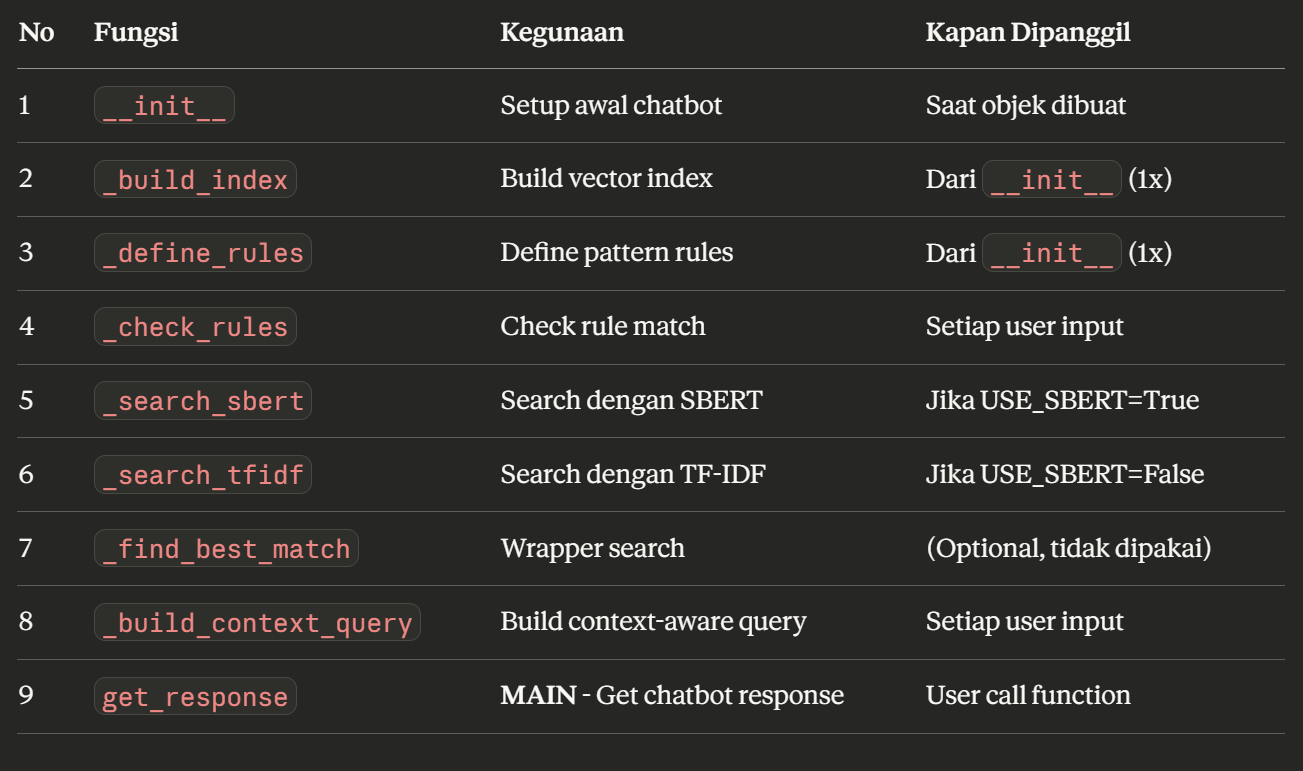



Kuis 3 Berdasarkan kode dibawah, bisakah kalian tebak ini menggunakan sistem apa?

In [ ]:
class MedicalChatbotEngineV3:
    """
    Medical Chatbot Engine Version 3

    Upgrade dari v2:
    ✔ Rule-based lebih aman (tidak over-trigger)
    ✔ Top-K retrieval (bukan cuma 1 hasil)
    ✔ Conversation memory digunakan
    ✔ Hybrid scoring (SBERT + keyword)

    Class ini adalah "mesin" chatbot yang bisa:
    - Menjawab pertanyaan medis berdasarkan database FAQ
    - Deteksi emergency (darurat) dengan rule-based
    - Ingat konteks percakapan sebelumnya
    - Cari jawaban paling relevan dengan AI
    """

    # ========================================================================
    # FUNGSI 1: CONSTRUCTOR (__init__)
    # Fungsi ini OTOMATIS dijalankan saat chatbot dibuat
    # ========================================================================
    def __init__(self, dataframe, threshold=0.35, top_k=3):
        """
        Inisialisasi chatbot (setup awal)

        Parameter:
        ----------
        dataframe : pd.DataFrame
            Data FAQ yang berisi kolom:
            - question: pertanyaan original
            - processed_question: pertanyaan yang sudah di-preprocess
            - answer: jawaban
            - category: kategori penyakit

        threshold : float (default: 0.35)
            Batas minimal similarity score
            - Jika pakai SBERT: 0.35 (karena SBERT score tinggi)
            - Jika pakai TF-IDF: 0.15 (karena TF-IDF score rendah)
            Semakin tinggi threshold, semakin ketat filter

        top_k : int (default: 3)
            Berapa hasil teratas yang diambil untuk diproses
            Contoh: top_k=3 → ambil 3 pertanyaan paling mirip

        Yang Dilakukan:
        ---------------
        1. Simpan parameter ke objek (self)
        2. Inisialisasi conversation history
        3. Build index untuk search
        4. Define rules untuk emergency
        """

        # 1. SIMPAN DATAFRAME
        self.df = dataframe
        # Simpan dataframe ke dalam objek chatbot
        # Supaya fungsi lain bisa akses data FAQ ini
        # self.df = objek chatbot punya dataframe

        # 2. SET THRESHOLD (BATAS SIMILARITY)
        self.threshold = threshold if USE_SBERT else 0.15
        # Logika:
        # - Jika USE_SBERT = True → threshold = 0.35 (yang diberikan user)
        # - Jika USE_SBERT = False → threshold = 0.15 (lebih rendah untuk TF-IDF)
        # Kenapa beda? SBERT score biasanya 0.7-0.9, TF-IDF score 0.1-0.3

        # 3. SET TOP-K (BERAPA HASIL YANG DIAMBIL)
        self.top_k = top_k
        # Simpan top_k untuk dipakai di fungsi search
        # top_k = 3 → ambil 3 hasil teratas
        # top_k = 5 → ambil 5 hasil teratas

        # 4. INISIALISASI CONVERSATION HISTORY (RIWAYAT CHAT)
        self.conversation_history = []
        # Buat list kosong untuk simpan pertanyaan user sebelumnya
        # Contoh setelah chat:
        # self.conversation_history = [
        #     "apa itu diabetes",      # Pertanyaan 1
        #     "bagaimana gejalanya",   # Pertanyaan 2
        #     "cara mengobatinya"      # Pertanyaan 3
        # ]
        # Digunakan untuk: context-aware response (ingat konteks)

        # 5. BUILD INDEX (VECTORIZATION)
        self._build_index()
        # Panggil fungsi untuk:
        # - Convert semua pertanyaan FAQ ke vector (embedding)
        # - Simpan dalam self.sbert_embeddings atau self.tfidf_matrix
        # Dilakukan SEKALI di awal, tidak perlu diulang setiap chat

        # 6. DEFINE RULES (PATTERN MATCHING)
        self._define_rules()
        # Panggil fungsi untuk:
        # - Setup pattern untuk emergency (darurat)
        # - Setup pattern untuk greeting (salam)
        # Supaya chatbot bisa langsung respon tanpa search


    # ========================================================================
    # FUNGSI 2: BUILD INDEX (_build_index)
    # Fungsi untuk membuat index/katalog dari semua pertanyaan FAQ
    # ========================================================================
    def _build_index(self):
        """
        Build index untuk search

        Proses:
        -------
        1. Jika pakai SBERT:
           - Encode semua pertanyaan FAQ ke vector (embedding)
           - Simpan dalam self.sbert_embeddings

        2. Buat TF-IDF vectorizer:
           - Belajar vocabulary dari semua pertanyaan
           - Transform semua pertanyaan ke TF-IDF vector
           - Simpan dalam self.tfidf_matrix

        Kenapa perlu index?
        -------------------
        Supaya search jadi CEPAT!

        Tanpa index:
        User: "gejala diabetes"
        → Cek satu per satu 1000 pertanyaan (LAMBAT!)

        Dengan index:
        User: "gejala diabetes" → Vector: [0.1, 0.5, ...]
        → Langsung cocokkan dengan vector FAQ (CEPAT!)
        """

        # A. BUILD SBERT EMBEDDINGS (JIKA DIAKTIFKAN)
        if USE_SBERT:
            # USE_SBERT = flag global yang menentukan pakai SBERT atau tidak
            # Jika True, jalankan code di bawah

            self.sbert_embeddings = SBERT_MODEL.encode(
                # SBERT_MODEL = model pre-trained (contoh: all-MiniLM-L6-v2)

                self.df['question'].tolist(),
                # Ambil semua pertanyaan dari kolom 'question'
                # .tolist() = convert pandas Series ke Python list
                # Contoh: ["apa itu diabetes", "gejala covid", ...]

                convert_to_tensor=True
                # Simpan hasil dalam format PyTorch tensor
                # Tensor = array multi-dimensi untuk operasi cepat
                # Jika False → return numpy array
                # Jika True → return torch tensor (lebih cepat untuk GPU)
            )

            # Hasil:
            # self.sbert_embeddings = tensor berisi semua embedding
            # Shape: (jumlah_pertanyaan, 384)
            # Contoh: (1000, 384) = 1000 pertanyaan, masing-masing 384 dimensi
            #
            # Contoh isi:
            # [[0.123, 0.456, 0.789, ...],  # Pertanyaan 1
            #  [0.321, 0.654, 0.987, ...],  # Pertanyaan 2
            #  ...]

        # B. BUILD TF-IDF VECTORIZER
        self.vectorizer = TfidfVectorizer(
            # TfidfVectorizer = class dari sklearn untuk TF-IDF

            ngram_range=(1, 2),
            # Ambil 1-word dan 2-word phrases
            # (1, 1) = hanya 1-word: ["apa", "itu", "diabetes"]
            # (1, 2) = 1-word + 2-word: ["apa", "itu", "diabetes", "apa itu", "itu diabetes"]
            # Kenapa? 2-word lebih akurat untuk medical terms
            # Contoh: "diabetes mellitus" lebih spesifik dari "diabetes"

            max_features=5000,
            # Maksimal 5000 kata/phrase unik yang disimpan
            # Jika vocabulary > 5000, ambil 5000 yang paling penting
            # Kenapa dibatasi? Supaya tidak terlalu besar (memory efficient)

            sublinear_tf=True
            # Gunakan logarithmic term frequency
            # TF biasa: count kata
            # Sublinear TF: 1 + log(count)
            # Kenapa? Supaya kata yang muncul 100x tidak terlalu dominan
            # Contoh:
            # - Kata muncul 1x: TF = 1
            # - Kata muncul 10x: TF biasa = 10, sublinear = 1 + log(10) = 2
            # - Kata muncul 100x: TF biasa = 100, sublinear = 1 + log(100) = 3
        )

        # C. FIT & TRANSFORM (BELAJAR + CONVERT)
        self.tfidf_matrix = self.vectorizer.fit_transform(
            # fit_transform = 2 langkah sekaligus:
            # 1. fit() = belajar vocabulary dari data
            # 2. transform() = convert text ke vector

            self.df['processed_question']
            # Gunakan kolom 'processed_question' (sudah di-preprocess)
            # Bukan 'question' (masih kotor)
            # Preprocess contoh: "Apa itu DIABETES?" → "apa itu diabetes"
        )

        # Proses di balik layar:
        #
        # Input (processed_question):
        # ["apa itu diabetes", "gejala covid", "cara minum obat"]
        #
        # Step 1: Belajar vocabulary (fit)
        # Vocabulary = {
        #     "apa": 0,
        #     "itu": 1,
        #     "diabetes": 2,
        #     "gejala": 3,
        #     "covid": 4,
        #     "cara": 5,
        #     "minum": 6,
        #     "obat": 7,
        #     "apa itu": 8,
        #     "itu diabetes": 9,
        #     ...
        # }
        #
        # Step 2: Convert ke vector (transform)
        # "apa itu diabetes" → [0.5, 0.5, 0.7, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6, 0.6, ...]
        #                       ↑    ↑    ↑                               ↑    ↑
        #                      apa  itu  diabetes                    apa_itu itu_diabetes
        #
        # "gejala covid" → [0.0, 0.0, 0.0, 0.8, 0.6, 0.0, 0.0, 0.0, 0.0, 0.0, ...]
        #                                  ↑    ↑
        #                               gejala covid
        #
        # Hasil:
        # self.tfidf_matrix = sparse matrix berisi semua TF-IDF vector
        # Shape: (jumlah_pertanyaan, jumlah_vocabulary)
        # Contoh: (1000, 5000) = 1000 pertanyaan, 5000 kata unik


    # ========================================================================
    # FUNGSI 3: DEFINE RULES (_define_rules)
    # Fungsi untuk mendefinisikan pattern matching rules
    # ========================================================================
    def _define_rules(self):
        """
        Define rule-based responses

        Konsep:
        -------
        Rule-based = response berdasarkan pattern matching
        Tidak perlu search database, langsung return response

        Kegunaan:
        ---------
        1. Emergency (darurat): Deteksi kondisi berbahaya
        2. Greeting (salam): Sapaan awal
        3. FAQ umum: Pertanyaan yang sering muncul

        Kenapa pakai rules?
        -------------------
        - CEPAT: Tidak perlu search
        - AKURAT: 100% pasti untuk pattern tertentu
        - AMAN: Emergency tidak boleh salah
        - PRIORITAS: Bypass semantic search
        """

        self.rules = {
            # Dictionary berisi semua rules
            # Format: {'intent_name': {'patterns': [...], 'responses': [...]}}

            # RULE 1: EMERGENCY (DARURAT)
            'emergency': {
                # Intent name = 'emergency'
                # Untuk deteksi kondisi darurat yang butuh penanganan segera

                'patterns': [
                    # List berisi regex pattern untuk emergency
                    # Regex = Regular Expression (pattern matching)

                    r'(sesak.*berat|nyeri dada.*berat|tidak.*bernapas|pingsan)',
                    # Pattern breakdown:
                    # (                    : Start group
                    #   sesak.*berat       : "sesak" + any chars + "berat"
                    #   |                  : OR
                    #   nyeri dada.*berat  : "nyeri dada" + any chars + "berat"
                    #   |                  : OR
                    #   tidak.*bernapas    : "tidak" + any chars + "bernapas"
                    #   |                  : OR
                    #   pingsan            : exact word "pingsan"
                    # )                    : End group
                    #
                    # Contoh MATCH:
                    # ✅ "saya sesak napas sangat berat"
                    # ✅ "nyeri dada sebelah kiri berat"
                    # ✅ "anak tidak bisa bernapas"
                    # ✅ "ibu saya pingsan"
                    #
                    # Contoh TIDAK MATCH:
                    # ❌ "sesak napas biasa" (tidak ada "berat")
                    # ❌ "nyeri kepala berat" (bukan "nyeri dada")
                ],

                'responses': [
                    # List berisi response yang mungkin
                    # Nanti dipilih random

                    "🚨 DARURAT! Hubungi 119 atau segera ke IGD!"
                    # Response untuk emergency
                    # Jelas, tegas, actionable
                ]
            },

            # RULE 2: GREETING (SALAM)
            'greeting': {
                # Intent name = 'greeting'
                # Untuk deteksi sapaan dari user

                'patterns': [
                    r'\b(halo|hai|hi|hello)\b'
                    # Pattern breakdown:
                    # \b           : Word boundary (awal kata)
                    # (            : Start group
                    #   halo       : "halo"
                    #   |          : OR
                    #   hai        : "hai"
                    #   |          : OR
                    #   hi         : "hi"
                    #   |          : OR
                    #   hello      : "hello"
                    # )            : End group
                    # \b           : Word boundary (akhir kata)
                    #
                    # Kenapa pakai \b?
                    # Supaya hanya match kata utuh, bukan bagian kata
                    #
                    # Contoh MATCH:
                    # ✅ "halo dok"
                    # ✅ "hai, ada yang bisa dibantu?"
                    # ✅ "hi there"
                    #
                    # Contoh TIDAK MATCH:
                    # ❌ "haloooo" (tidak ada word boundary)
                    # ❌ "ohalo" (di tengah kata)
                ],

                'responses': [
                    "👋 Halo! Ada yang bisa saya bantu?"
                    # Response ramah untuk greeting
                    # Bisa lebih dari 1 response (dipilih random)
                ]
            }

            # Bisa ditambah rule lain:
            # 'goodbye': {...}
            # 'faq_umum': {...}
            # 'out_of_scope': {...}
        }


    # ========================================================================
    # FUNGSI 4: CHECK RULES (_check_rules)
    # Fungsi untuk mengecek apakah user input match dengan rule
    # ========================================================================
    def _check_rules(self, text):
        """
        Check apakah text match dengan rule yang didefinisikan

        Parameter:
        ----------
        text : str
            Input dari user
            Contoh: "halo dok", "saya pingsan", "apa itu diabetes"

        Return:
        -------
        str or None
            - Jika match: return response dari rule
            - Jika tidak match: return None

        Flow:
        -----
        1. Loop semua intent (emergency, greeting, ...)
        2. Untuk setiap intent, loop semua pattern
        3. Jika ada pattern yang match, return response
        4. Jika tidak ada yang match, return None
        """

        # LOOP SEMUA RULES
        for intent, data in self.rules.items():
            # intent = nama intent ('emergency', 'greeting', ...)
            # data = dictionary berisi 'patterns' dan 'responses'
            #
            # Contoh iterasi 1:
            # intent = 'emergency'
            # data = {
            #     'patterns': [r'(sesak.*berat|...)'],
            #     'responses': ["🚨 DARURAT! ..."]
            # }
            #
            # Contoh iterasi 2:
            # intent = 'greeting'
            # data = {
            #     'patterns': [r'\b(halo|hai)\b'],
            #     'responses': ["👋 Halo! ..."]
            # }

            # LOOP SEMUA PATTERN DALAM INTENT
            for pattern in data['patterns']:
                # pattern = regex pattern (contoh: r'\b(halo|hai)\b')

                # CHECK MATCH DENGAN REGEX
                if re.search(pattern, text.lower()):
                    # re.search(pattern, text)
                    # = cari pattern dalam text
                    # Return: Match object jika ketemu, None jika tidak
                    #
                    # text.lower()
                    # = convert text ke lowercase dulu
                    # Supaya case-insensitive
                    # "HALO" dan "halo" sama saja
                    #
                    # Contoh:
                    # text = "HALO DOK"
                    # text.lower() = "halo dok"
                    # pattern = r'\b(halo|hai)\b'
                    # re.search(r'\b(halo|hai)\b', "halo dok")
                    # = MATCH! (ketemu "halo")

                    # JIKA MATCH, RETURN RESPONSE
                    return random.choice(data['responses'])
                    # random.choice() = pilih 1 random dari list
                    #
                    # Contoh:
                    # data['responses'] = [
                    #     "Response 1",
                    #     "Response 2",
                    #     "Response 3"
                    # ]
                    # random.choice(...) = "Response 2" (random)
                    #
                    # Kenapa random?
                    # Supaya response tidak monoton
                    # Setiap kali user say "halo", response bisa beda

        # JIKA TIDAK ADA YANG MATCH
        return None
        # Return None = signal bahwa tidak ada rule yang match
        # Nanti dilanjutkan dengan semantic search


    # ========================================================================
    # FUNGSI 5: SEARCH SBERT (_search_sbert)
    # Fungsi untuk search menggunakan SBERT embeddings
    # ========================================================================
    def _search_sbert(self, query):
        """
        Search FAQ menggunakan SBERT semantic similarity

        Parameter:
        ----------
        query : str
            Pertanyaan dari user
            Contoh: "apa gejala diabetes"

        Return:
        -------
        list of tuple
            List berisi (index, score) untuk top-k hasil
            Contoh: [(45, 0.91), (23, 0.85), (67, 0.77)]
            = Index 45 paling mirip (score 0.91)

        Flow:
        -----
        1. Encode query ke vector (embedding)
        2. Hitung cosine similarity dengan semua FAQ
        3. Ambil top-k hasil dengan score tertinggi
        4. Return list (index, score)

        Keuntungan SBERT:
        -----------------
        - Semantic understanding (paham makna)
        - "gejala diabetes" mirip dengan "tanda-tanda diabetes"
        - Lebih akurat dari keyword matching
        """

        # IMPORT UTILITY FUNCTION
        from sentence_transformers import util
        # util.cos_sim = function untuk hitung cosine similarity

        # STEP 1: ENCODE QUERY
        emb = SBERT_MODEL.encode(query, convert_to_tensor=True)
        # SBERT_MODEL = model pre-trained (contoh: all-MiniLM-L6-v2)
        #
        # Proses:
        # Input:  "apa gejala diabetes"
        # Output: tensor([0.123, 0.456, 0.789, ...])
        #         = vector 384 dimensi
        #
        # convert_to_tensor=True
        # = return PyTorch tensor (bukan numpy array)
        # Kenapa? Supaya bisa pakai GPU (lebih cepat)

        # STEP 2: HITUNG COSINE SIMILARITY
        scores = util.cos_sim(emb, self.sbert_embeddings)[0]
        # util.cos_sim(A, B)
        # = hitung cosine similarity antara A dan B
        #
        # emb = query vector
        # Shape: (1, 384) = 1 query, 384 dimensi
        #
        # self.sbert_embeddings = FAQ vectors
        # Shape: (N, 384) = N pertanyaan, 384 dimensi
        #
        # Output:
        # Shape: (1, N) = 1 query vs N pertanyaan
        #
        # [0] = ambil row pertama
        # Hasil: tensor([0.85, 0.23, 0.91, 0.15, ...])
        #         ↑      ↑      ↑      ↑
        #        Q1     Q2     Q3     Q4
        #
        # Cosine Similarity Formula:
        # similarity = (A · B) / (||A|| * ||B||)
        # = dot product dibagi magnitude
        # Range: -1 (berlawanan) sampai 1 (sama persis)
        # Medical context: biasanya 0.3 - 0.9
        #
        # Contoh interpretasi:
        # 0.9 - 1.0 = hampir identik
        # 0.7 - 0.9 = sangat mirip
        # 0.5 - 0.7 = cukup mirip
        # 0.3 - 0.5 = agak mirip
        # < 0.3 = tidak mirip

        # STEP 3: CONVERT TO NUMPY
        scores = scores.cpu().numpy()
        # .cpu() = pindah dari GPU ke CPU (jika pakai GPU)
        # .numpy() = convert PyTorch tensor ke numpy array
        # Kenapa? Supaya bisa pakai np.argsort() di step berikutnya

        # STEP 4: GET TOP-K INDICES
        top_results = np.argsort(-scores)[:self.top_k]
        # np.argsort(scores)
        # = return indices yang mengurutkan array dari kecil ke besar
        #
        # Contoh:
        # scores = [0.85, 0.23, 0.91, 0.15, 0.77]
        # np.argsort(scores) = [3, 1, 4, 0, 2]
        #                       ↑  ↑  ↑  ↑  ↑
        #                     0.15 → 0.23 → 0.77 → 0.85 → 0.91
        #
        # np.argsort(-scores)
        # = argsort dari score negatif = descending order
        #
        # -scores = [-0.85, -0.23, -0.91, -0.15, -0.77]
        # np.argsort(-scores) = [2, 0, 4, 1, 3]
        #                        ↑  ↑  ↑  ↑  ↑
        #                      0.91 → 0.85 → 0.77 → 0.23 → 0.15
        #
        # [:self.top_k]
        # = ambil k hasil teratas
        # Jika top_k = 3, ambil [2, 0, 4]

        # STEP 5: RETURN RESULTS
        return [(idx, float(scores[idx])) for idx in top_results]
        # List comprehension untuk format hasil
        #
        # Contoh:
        # top_results = [2, 0, 4]
        # scores = [0.85, 0.23, 0.91, 0.15, 0.77]
        #
        # Iterasi:
        # idx=2: (2, float(scores[2])) = (2, 0.91)
        # idx=0: (0, float(scores[0])) = (0, 0.85)
        # idx=4: (4, float(scores[4])) = (4, 0.77)
        #
        # Return:
        # [(2, 0.91), (0, 0.85), (4, 0.77)]
        # = Index 2 paling mirip (score 0.91)
        #
        # float(scores[idx])
        # = convert numpy float ke Python float
        # Kenapa? Supaya bisa di-serialize (JSON, pickle, dll)


    # ========================================================================
    # FUNGSI 6: SEARCH TF-IDF (_search_tfidf)
    # Fungsi untuk search menggunakan TF-IDF + cosine similarity
    # ========================================================================
    def _search_tfidf(self, query):
        """
        Search FAQ menggunakan TF-IDF + cosine similarity

        Parameter:
        ----------
        query : str
            Pertanyaan dari user
            Contoh: "apa gejala diabetes"

        Return:
        -------
        list of tuple
            List berisi (index, score) untuk top-k hasil
            Contoh: [(45, 0.31), (23, 0.25), (67, 0.22)]

        Flow:
        -----
        1. Preprocess query (lowercase, stemming, dll)
        2. Transform query ke TF-IDF vector
        3. Hitung cosine similarity dengan FAQ matrix
        4. Ambil top-k hasil
        5. Return list (index, score)

        Perbedaan dengan SBERT:
        -----------------------
        - TF-IDF: keyword-based (exact matching)
        - SBERT: semantic-based (makna)
        - TF-IDF lebih cepat, SBERT lebih akurat
        """

        # STEP 1: PREPROCESS QUERY
        processed = preprocess_text(query)
        # preprocess_text() = function untuk cleaning text
        #
        # Contoh:
        # Input:  "Apa GEJALA diabetes?"
        # Output: "apa gejala diabetes"
        #
        # Proses preprocessing:
        # 1. Lowercase: "Apa" → "apa"
        # 2. Remove punctuation: "diabetes?" → "diabetes"
        # 3. Stemming: "gejalanya" → "gejala"
        # 4. Remove stopwords: "adalah" → ""

        # STEP 2: TRANSFORM TO TF-IDF VECTOR
        vec = self.vectorizer.transform([processed])
        # self.vectorizer = TfidfVectorizer yang sudah di-fit saat __init__
        #
        # .transform([processed])
        # = convert text ke TF-IDF vector
        # [processed] = list berisi 1 text (harus list, bukan string)
        #
        # Proses:
        # Input:  "apa gejala diabetes"
        #
        # Step 1: Tokenize
        # ["apa", "gejala", "diabetes", "apa gejala", "gejala diabetes"]
        #
        # Step 2: Map ke vocabulary
        # Vocabulary (sudah dipelajari saat fit):
        # {
        #     "apa": 0,
        #     "gejala": 3,
        #     "diabetes": 2,
        #     "apa gejala": 8,
        #     "gejala diabetes": 10,
        #     ...
        # }
        #
        # Step 3: Hitung TF-IDF score
        # vec = [0.5, 0.0, 0.7, 0.8, ..., 0.6, ..., 0.5, ...]
        #        ↑         ↑    ↑         ↑         ↑
        #       apa     diabetes gejala  apa_gejala gejala_diabetes
        #
        # Output:
        # vec = sparse matrix (1, vocab_size)
        # Contoh: (1, 5000) = 1 query, 5000 features
        # Sparse = kebanyakan 0, hanya kata yang muncul yang ada value

        # STEP 3: HITUNG COSINE SIMILARITY
        scores = cosine_similarity(vec, self.tfidf_matrix).flatten()
        # cosine_similarity(A, B)
        # = hitung cosine similarity antara A dan B
        #
        # vec = query vector
        # Shape: (1, 5000)
        #
        # self.tfidf_matrix = FAQ matrix
        # Shape: (N, 5000) = N pertanyaan, 5000 features
        #
        # Output:
        # Shape: (1, N) = 1 query vs N pertanyaan
        #
        # .flatten()
        # = convert 2D array (1, N) ke 1D array (N,)
        #
        # Contoh:
        # [[0.31, 0.15, 0.28, 0.42, ...]]  # 2D
        # → [0.31, 0.15, 0.28, 0.42, ...]  # 1D
        #
        # Cosine Similarity (sama dengan SBERT):
        # similarity = (A · B) / (||A|| * ||B||)
        #
        # Interpretasi score TF-IDF:
        # > 0.3 = sangat mirip (banyak kata yang sama)
        # 0.2 - 0.3 = cukup mirip
        # 0.1 - 0.2 = agak mirip
        # < 0.1 = tidak mirip
        #
        # Catatan: TF-IDF score biasanya lebih rendah dari SBERT
        # Makanya threshold TF-IDF = 0.15, SBERT = 0.35

        # STEP 4: GET TOP-K INDICES
        top_results = np.argsort(scores)[::-1][:self.top_k]
        # np.argsort(scores)
        # = return indices dari kecil ke besar
        #
        # [::-1]
        # = reverse (jadi dari besar ke kecil)
        #
        # [:self.top_k]
        # = ambil k teratas
        #
        # Contoh:
        # scores = [0.31, 0.15, 0.28, 0.42, 0.19]
        #
        # np.argsort(scores) = [1, 4, 2, 0, 3]
        #                       ↑  ↑  ↑  ↑  ↑
        #                     0.15 → 0.19 → 0.28 → 0.31 → 0.42
        #
        # [::-1] = [3, 0, 2, 4, 1]
        #           ↑  ↑  ↑  ↑  ↑
        #         0.42 → 0.31 → 0.28 → 0.19 → 0.15
        #
        # [:3] = [3, 0, 2]  # top-3

        # STEP 5: RETURN RESULTS
        return [(idx, scores[idx]) for idx in top_results]
        # Format sama dengan _search_sbert()
        #
        # Contoh:
        # top_results = [3, 0, 2]
        # scores = [0.31, 0.15, 0.28, 0.42, 0.19]
        #
        # Return:
        # [(3, 0.42), (0, 0.31), (2, 0.28)]


    # ========================================================================
    # FUNGSI 7: FIND BEST MATCH (_find_best_match)
    # Fungsi wrapper untuk memilih search method
    # ========================================================================
    def _find_best_match(self, query):
        """
        Find best matching FAQ untuk query

        Parameter:
        ----------
        query : str
            Pertanyaan dari user

        Return:
        -------
        tuple
            (best_idx, best_score)
            best_idx = index FAQ yang paling cocok
            best_score = similarity score

        Flow:
        -----
        1. Pilih search method (SBERT atau TF-IDF)
        2. Ambil hasil teratas (best result)
        3. Return index dan score

        Catatan:
        --------
        Fungsi ini sebenarnya tidak dipakai di get_response()
        Karena get_response() langsung panggil _search_sbert()
        atau _search_tfidf()

        Fungsi ini bisa dipakai untuk simple use case
        yang cuma butuh 1 hasil terbaik
        """

        # PILIH SEARCH METHOD
        if USE_SBERT:
            # Jika USE_SBERT = True, pakai SBERT
            results = self._search_sbert(query)
        else:
            # Jika USE_SBERT = False, pakai TF-IDF
            results = self._search_tfidf(query)

        # AMBIL HASIL TERATAS
        best_idx, best_score = results[0]
        # results = [(idx1, score1), (idx2, score2), ...]
        # results[0] = (idx1, score1) = hasil terbaik
        #
        # Contoh:
        # results = [(45, 0.91), (23, 0.85), (67, 0.77)]
        # results[0] = (45, 0.91)
        # best_idx = 45
        # best_score = 0.91

        # RETURN
        return best_idx, best_score


    # ========================================================================
    # FUNGSI 8: BUILD CONTEXT QUERY (_build_context_query)
    # Fungsi untuk membuat query yang context-aware
    # ========================================================================
    def _build_context_query(self, user_input):
        """
        Build query dengan konteks dari percakapan sebelumnya

        Parameter:
        ----------
        user_input : str
            Input terbaru dari user
            Contoh: "bagaimana gejalanya"

        Return:
        -------
        str
            Query yang sudah digabung dengan konteks
            Contoh: "apa itu diabetes bagaimana gejalanya"

        Kenapa perlu context?
        ---------------------
        Percakapan normal sering tidak lengkap:

        User: "apa itu diabetes"
        Bot: "Diabetes adalah penyakit..."
        User: "bagaimana gejalanya"  ← TIDAK JELAS!

        Tanpa context:
        - "bagaimana gejalanya" → gejala apa?
        - Bot bingung

        Dengan context:
        - Gabung dengan pertanyaan sebelumnya
        - "apa itu diabetes bagaimana gejalanya"
        - Bot paham: gejala DIABETES

        Implementasi:
        -------------
        - Ambil 1 pertanyaan sebelumnya
        - Gabung dengan pertanyaan sekarang
        - Search dengan query gabungan
        """

        # CEK APAKAH ADA HISTORY
        if len(self.conversation_history) > 0:
            # Jika ada riwayat percakapan (list tidak kosong)

            # AMBIL PERTANYAAN TERAKHIR
            last_input = self.conversation_history[-1]
            # [-1] = elemen terakhir dalam list
            #
            # Contoh:
            # self.conversation_history = [
            #     "apa itu diabetes",       # [0]
            #     "cara mengobatinya",      # [1]
            #     "efek sampingnya"         # [2] = [-1]
            # ]
            # last_input = "efek sampingnya"

            # GABUNG DENGAN INPUT BARU
            return last_input + " " + user_input
            # Concatenate (gabung string)
            #
            # Contoh:
            # last_input = "apa itu diabetes"
            # user_input = "bagaimana gejalanya"
            # return = "apa itu diabetes bagaimana gejalanya"
            #
            # Query gabungan ini akan di-search
            # Bot akan cari FAQ yang match dengan:
            # "apa itu diabetes bagaimana gejalanya"
            # → lebih spesifik dari cuma "bagaimana gejalanya"

        # JIKA TIDAK ADA HISTORY
        return user_input
        # Return query original (tanpa modifikasi)
        #
        # Contoh:
        # user_input = "apa itu diabetes"
        # return = "apa itu diabetes"


    # ========================================================================
    # FUNGSI 9: GET RESPONSE (get_response) - MAIN FUNCTION
    # Fungsi utama untuk mendapatkan response dari chatbot
    # ========================================================================
    def get_response(self, user_input):
        """
        Get response dari chatbot untuk user input

        Parameter:
        ----------
        user_input : str
            Pertanyaan/input dari user
            Contoh: "apa gejala diabetes"

        Return:
        -------
        str
            Response dari chatbot
            Bisa berupa:
            - Rule-based response (emergency, greeting)
            - FAQ answer dari database
            - "Tidak menemukan jawaban" (jika score rendah)

        Flow Lengkap:
        -------------
        1. Validasi input (tidak boleh kosong)
        2. Check rules (emergency, greeting)
        3. Build context query (gabung dengan history)
        4. Search FAQ (SBERT atau TF-IDF)
        5. Filter by threshold (buang hasil tidak relevan)
        6. Re-rank dengan keyword boost (opsional)
        7. Ambil jawaban terbaik
        8. Save ke history
        9. Return formatted response

        Ini adalah fungsi yang dipanggil user!
        """

        # STEP 1: VALIDASI INPUT
        if not user_input.strip():
            # .strip() = remove whitespace di awal/akhir
            # not ... = jika kosong/whitespace saja
            #
            # Contoh yang kena validasi:
            # ""       → kosong
            # "   "    → whitespace saja
            # "\n\t"   → newline/tab saja

            return "Silakan ketik pertanyaan."
            # Return pesan error
            # Stop execution (tidak lanjut ke step berikutnya)

        # STEP 2: CHECK RULES (PRIORITY PERTAMA)
        rule = self._check_rules(user_input)
        # Panggil fungsi _check_rules()
        # Return: response string atau None
        #
        # Contoh:
        # user_input = "halo dok"
        # rule = "👋 Halo! Ada yang bisa saya bantu?"
        #
        # user_input = "apa itu diabetes"
        # rule = None

        if rule:
            # Jika rule tidak None (ada pattern yang match)
            return rule
            # Langsung return rule response
            # BYPASS search database (lebih cepat!)
            #
            # Contoh:
            # user_input = "saya pingsan"
            # return "🚨 DARURAT! Hubungi 119..."

        # STEP 3: BUILD CONTEXT QUERY
        query = self._build_context_query(user_input)
        # Gabung dengan history jika ada
        #
        # Contoh:
        # user_input = "bagaimana gejalanya"
        # history = ["apa itu diabetes"]
        # query = "apa itu diabetes bagaimana gejalanya"

        # STEP 4: SEARCH FAQ
        if USE_SBERT:
            # Jika pakai SBERT
            results = self._search_sbert(query)
            method = "SBERT"
            # results = [(idx1, score1), (idx2, score2), (idx3, score3)]
            # method = string untuk display di response
        else:
            # Jika pakai TF-IDF
            results = self._search_tfidf(query)
            method = "TF-IDF"

        # STEP 5: AMBIL HASIL TERBAIK
        best_idx, best_score = results[0]
        # results[0] = hasil dengan score tertinggi
        #
        # Contoh:
        # results = [(45, 0.91), (23, 0.85), (67, 0.77)]
        # best_idx = 45
        # best_score = 0.91

        # STEP 6: FILTER BY THRESHOLD
        if best_score < self.threshold:
            # Jika score terlalu rendah (tidak cukup mirip)
            #
            # Contoh:
            # best_score = 0.20
            # self.threshold = 0.35
            # 0.20 < 0.35 → True → tidak relevan

            return "🤔 Tidak menemukan jawaban yang cukup relevan."
            # Return pesan "tidak tahu"
            # Lebih baik admit tidak tahu
            # Daripada kasih jawaban salah

        # STEP 7: RE-RANK DENGAN KEYWORD BOOST (OPSIONAL)
        boosted = []
        # List untuk simpan hasil re-ranking

        for idx, score in results:
            # Loop semua hasil (top-k)
            #
            # Contoh iterasi:
            # idx = 45, score = 0.91
            # idx = 23, score = 0.85
            # idx = 67, score = 0.77

            # AMBIL TEKS PERTANYAAN FAQ
            text = self.df.iloc[idx]['question']
            # self.df.iloc[idx] = row di dataframe
            # ['question'] = kolom question
            #
            # Contoh:
            # idx = 45
            # text = "apa saja gejala diabetes mellitus"

            # HITUNG KEYWORD BONUS
            bonus = sum(1 for word in user_input.split() if word in text)
            # user_input.split() = ["apa", "gejala", "diabetes"]
            #
            # Loop setiap kata:
            # - "apa" in text? Yes → +1
            # - "gejala" in text? Yes → +1
            # - "diabetes" in text? Yes → +1
            # bonus = 3
            #
            # Kenapa perlu bonus?
            # Kadang SBERT terlalu "smart"
            # Dia match berdasarkan makna, bukan exact word
            # Kita boost hasil yang punya exact keyword match
            #
            # Contoh:
            # Query: "gejala diabetes"
            #
            # Hasil SBERT:
            # 1. "tanda-tanda kencing manis" (score 0.88)
            # 2. "gejala diabetes mellitus" (score 0.85)
            #
            # Setelah keyword boost:
            # 1. "tanda-tanda kencing manis" (0.88 + 0)
            # 2. "gejala diabetes mellitus" (0.85 + 0.10) = 0.95 ✅

            # SIMPAN HASIL BOOST
            boosted.append((idx, score + 0.05 * bonus))
            # score + 0.05 * bonus
            # = score original + keyword bonus
            #
            # Contoh:
            # score = 0.85
            # bonus = 3
            # new_score = 0.85 + (0.05 * 3) = 0.85 + 0.15 = 1.00
            #
            # boosted = [
            #     (45, 0.91 + 0.15),  # ada 3 keyword match
            #     (23, 0.85 + 0.00),  # tidak ada keyword match
            #     (67, 0.77 + 0.05)   # ada 1 keyword match
            # ]

        # STEP 8: AMBIL TERBAIK SETELAH BOOST
        best_idx = sorted(boosted, key=lambda x: x[1], reverse=True)[0][0]
        # sorted(boosted, key=..., reverse=True)
        # = sort dari score tertinggi ke terendah
        #
        # key=lambda x: x[1]
        # = sort berdasarkan elemen ke-2 (score)
        #
        # [0] = ambil elemen pertama (score tertinggi)
        # [0] = ambil index (elemen pertama dari tuple)
        #
        # Contoh:
        # boosted = [(45, 1.06), (23, 0.85), (67, 0.82)]
        # sorted(...) = [(45, 1.06), (23, 0.85), (67, 0.82)]
        # [0] = (45, 1.06)
        # [0] = 45
        # best_idx = 45

        # STEP 9: AMBIL DATA FAQ
        row = self.df.iloc[best_idx]
        # self.df.iloc[45] = row ke-45 di dataframe
        #
        # Contoh:
        # row = {
        #     'question': 'apa gejala diabetes',
        #     'answer': 'Gejala diabetes meliputi...',
        #     'category': 'Diabetes',
        #     'processed_question': 'apa gejala diabetes'
        # }

        # STEP 10: SAVE KE HISTORY
        self.conversation_history.append(user_input)
        # Tambah user input ke history
        # Supaya bisa dipakai untuk context di query berikutnya
        #
        # Sebelum:
        # self.conversation_history = []
        #
        # Setelah query 1:
        # self.conversation_history = ["apa itu diabetes"]
        #
        # Setelah query 2:
        # self.conversation_history = ["apa itu diabetes", "bagaimana gejalanya"]

        # STEP 11: FORMAT & RETURN RESPONSE
        return f"""
[Kategori: {row['category']} | {method}]

{row['answer']}

─────────────────
⚠️ Untuk kondisi serius, konsultasikan ke dokter.
"""
        # f-string = formatted string
        # {variable} = insert variable value
        #
        # Contoh output:
        # """
        # [Kategori: Diabetes | SBERT]
        #
        # Gejala diabetes meliputi:
        # - Sering haus
        # - Sering buang air kecil
        # - Mudah lelah
        # - Penurunan berat badan
        #
        # ─────────────────
        # ⚠️ Untuk kondisi serius, konsultasikan ke dokter.
        # """

## LANGKAH 6: Tampilan Interaktif di Google Colab

`ipywidgets` untuk membuat UI chat yang interaktif langsung di Colab. Ini memungkinkan pengguna berinteraksi dengan chatbot tanpa perlu menjalankan ulang cell setiap saat.

In [ ]:
# UI CHATBOT INTERAKTIF
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

chat_css = """
<style>
  @import url('https://fonts.googleapis.com/css2?family=Plus+Jakarta+Sans:wght@400;500;600;700&display=swap');
  .medbot-container { font-family: 'Plus Jakarta Sans', sans-serif; max-width: 720px; margin: 0 auto; border-radius: 20px; overflow: hidden; box-shadow: 0 20px 60px rgba(0,0,0,0.15); background: #f8faff; }
  .medbot-header { background: linear-gradient(135deg, #1a1f5e 0%, #2d3a8c 50%, #1565c0 100%); padding: 20px 24px; color: white; display: flex; align-items: center; gap: 14px; }
  .medbot-avatar { width: 48px; height: 48px; background: rgba(255,255,255,0.2); border-radius: 50%; display: flex; align-items: center; justify-content: center; font-size: 24px; border: 2px solid rgba(255,255,255,0.4); }
  .medbot-title { font-size: 18px; font-weight: 700; }
  .medbot-subtitle { font-size: 12px; opacity: 0.75; margin-top: 2px; }
  .status-dot { width:8px; height:8px; background:#4ade80; border-radius:50%; display:inline-block; margin-right:5px; animation: pulse 2s infinite; }
  @keyframes pulse { 0%,100%{opacity:1} 50%{opacity:0.5} }
  .medbot-chat { height: 400px; overflow-y: auto; padding: 20px; background: #f0f4ff; display: flex; flex-direction: column; gap: 14px; }
  .message-row-user { display:flex; justify-content:flex-end; }
  .message-row-bot  { display:flex; justify-content:flex-start; align-items:flex-start; gap:10px; }
  .bot-icon { width: 32px; height: 32px; min-width: 32px; background: linear-gradient(135deg, #1565c0, #2d3a8c); border-radius: 50%; display: flex; align-items:center; justify-content:center; font-size: 14px; }
  .bubble-user { background: linear-gradient(135deg, #1565c0, #2d3a8c); color: white; padding: 12px 16px; border-radius: 18px 18px 4px 18px; max-width: 75%; font-size: 14px; line-height: 1.5; }
  .bubble-bot { background: white; color: #1a1a2e; padding: 12px 16px; border-radius: 18px 18px 18px 4px; max-width: 80%; font-size: 13.5px; line-height: 1.65; box-shadow: 0 2px 10px rgba(0,0,0,0.08); border: 1px solid #e8eeff; white-space: pre-wrap; }
  .disclaimer { background: #fff8e1; border-left: 3px solid #f59e0b; padding: 10px 14px; font-size: 11.5px; color: #78350f; }
  .quick-chips { padding: 10px 16px; background: white; border-top: 1px solid #f0f0ff; display: flex; gap: 8px; flex-wrap: wrap; }
  .chip { background: #eef2ff; color: #2d3a8c; border: 1px solid #c7d2fe; border-radius: 20px; padding: 5px 12px; font-size: 12px; font-weight: 500; cursor: pointer; font-family: inherit; }
  .chip:hover { background: #2d3a8c; color: white; }
  .badge-sbert { background: #d1fae5; color: #065f46; border-radius: 12px; padding: 2px 8px; font-size: 10px; font-weight: 600; margin-left: 8px; }
</style>
"""

chat_messages = []

def render_chat():
    mode_badge = '<span class="badge-sbert">Sentence-BERT</span>' if USE_SBERT else '<span style="background:#fee2e2;color:#991b1b;border-radius:12px;padding:2px 8px;font-size:10px;font-weight:600;margin-left:8px;">TF-IDF</span>'
    html = chat_css
    html += '<div class="medbot-container">'
    html += f'''
    <div class="medbot-header">
      <div class="medbot-avatar">🏥</div>
      <div>
        <div class="medbot-title">MedBot v2 — Asisten Kesehatan{mode_badge}</div>
        <div class="medbot-subtitle"><span class="status-dot"></span>Online · Semantic Medical QA Engine</div>
      </div>
    </div>
    '''
    html += '<div class="disclaimer">⚠️ MedBot hanya untuk edukasi. Bukan pengganti dokter. Darurat medis: hubungi 119.</div>'
    html += '''
    <div class="quick-chips">
      <span class="chip">🤕 Sakit Kepala</span>
      <span class="chip">🩸 Diabetes</span>
      <span class="chip">❤️ Jantung</span>
      <span class="chip">🫁 Asma</span>
      <span class="chip">🦠 COVID-19</span>
      <span class="chip">🧠 Mental</span>
    </div>
    '''
    html += '<div class="medbot-chat">'
    if not chat_messages:
        html += '<div class="message-row-bot"><div class="bot-icon">🤖</div><div class="bubble-bot">👋 Halo! Saya <strong>MedBot v2</strong>, kini dengan <strong>Sentence-BERT</strong> untuk pemahaman bahasa yang lebih baik!\n\nTopik baru: 🤕 Sakit kepala & migrain\n\nSilakan ketik pertanyaan kesehatan Anda!</div></div>'
    for msg in chat_messages:
        if msg['role'] == 'user':
            html += f'<div class="message-row-user"><div class="bubble-user">{msg["content"]}</div></div>'
        else:
            html += f'<div class="message-row-bot"><div class="bot-icon">🤖</div><div class="bubble-bot">{msg["content"]}</div></div>'
    html += '</div></div>'
    return HTML(html)

text_input = widgets.Text(
    placeholder='Ketik pertanyaan... (coba: "sakit kepala", "gejala diabetes")',
    layout=widgets.Layout(width='82%', height='38px')
)
send_button = widgets.Button(description='Kirim 📤', button_style='primary', layout=widgets.Layout(width='10%', height='38px'))
clear_button = widgets.Button(description='Clear 🗑️', button_style='warning', layout=widgets.Layout(width='8%', height='38px'))
output_area = widgets.Output()

def send_message(b=None):
    global chat_messages
    user_text = text_input.value.strip()
    if not user_text:
        return
    chat_messages.append({'role': 'user', 'content': user_text})
    response = bot.get_response(user_text)
    chat_messages.append({'role': 'bot', 'content': response})
    text_input.value = ''
    with output_area:
        clear_output(wait=True)
        display(render_chat())

def clear_chat(b):
    global chat_messages
    chat_messages = []
    with output_area:
        clear_output(wait=True)
        display(render_chat())

send_button.on_click(send_message)
clear_button.on_click(clear_chat)
text_input.on_submit(lambda w: send_message())

input_bar = widgets.HBox([text_input, send_button, clear_button], layout=widgets.Layout(padding='10px', gap='8px'))

with output_area:
    display(render_chat())

display(output_area)
display(input_bar)
print("Tip: Ketik pertanyaan lalu tekan Enter atau klik 'Kirim'")

Output()

Tip: Ketik pertanyaan lalu tekan Enter atau klik 'Kirim'


In [ ]:
import gradio as gr

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# INIT BOT

bot = MedicalChatbotEngineV3(df)


# RESPOND (STREAMING)

def respond(message, history):

    if history is None:
        history = []

    # tampilkan typing effect
    history.append((message, "⏳ MedBot sedang mengetik"))
    yield "", history

    time.sleep(0.6)
    response = bot.get_response(message)

    # update chat
    history[-1] = (message, response)
    yield "", history



# CHIP RESPONSE

def respond_chip(message, history):

    if history is None:
        history = []

    response = bot.get_response(message)

    history.append((message, response))
    return "", history



# CLEAR CHAT + MEMORY RESET

def clear_chat():
    bot.conversation_history = []  # reset context
    return []

# CSS

custom_css = """
.gradio-container {
    font-family: 'Plus Jakarta Sans', sans-serif;
    background: #f0f4ff;
}

.chatbot {
    height: 420px;
}

/* USER */
.message.user-message {
    background: linear-gradient(135deg, #1565c0, #2d3a8c) !important;
    color: white !important;
    border-radius: 18px 18px 4px 18px !important;
}

/* BOT */
.message.bot-message {
    background: white !important;
    border-radius: 18px 18px 18px 4px !important;
    border: 1px solid #e8eeff;
}

.header {
    background: linear-gradient(135deg, #1a1f5e, #2d3a8c, #1565c0);
    padding: 20px;
    border-radius: 15px;
    color: white;
}

.disclaimer {
    background: #fff8e1;
    padding: 10px;
    font-size: 12px;
    border-left: 4px solid orange;
    margin-top: 10px;
}
"""



# UI

with gr.Blocks(css=custom_css) as demo:

    # HEADER
    gr.Markdown("""
    <div class="header">
        <h2>🏥 MedBot v3 — Smart Medical Assistant</h2>
        <p>🟢 Online · Context-Aware Semantic Engine</p>
    </div>
    """)

    # DISCLAIMER
    gr.Markdown("""
    <div class="disclaimer">
    ⚠️ Edukasi saja. Bukan pengganti dokter. Darurat: 119
    </div>
    """)

    chatbot = gr.Chatbot()
    msg = gr.Textbox(placeholder="Ketik pertanyaan kesehatan...")

    with gr.Row():
        send = gr.Button("Kirim 📤")
        clear = gr.Button("Clear 🗑️")

    # QUICK CHIPS
    with gr.Row():
        chip1 = gr.Button("🤕 Sakit Kepala")
        chip2 = gr.Button("🩸 Diabetes")
        chip3 = gr.Button("❤️ Jantung")
        chip4 = gr.Button("🫁 Asma")
        chip5 = gr.Button("🧠 Mental")

    # EVENT
    send.click(respond, [msg, chatbot], [msg, chatbot])
    msg.submit(respond, [msg, chatbot], [msg, chatbot])

    clear.click(clear_chat, None, chatbot, queue=False)

    # CHIP EVENTS
    chip1.click(lambda h: respond_chip("sakit kepala", h), chatbot, [msg, chatbot])
    chip2.click(lambda h: respond_chip("diabetes", h), chatbot, [msg, chatbot])
    chip3.click(lambda h: respond_chip("penyakit jantung", h), chatbot, [msg, chatbot])
    chip4.click(lambda h: respond_chip("asma", h), chatbot, [msg, chatbot])
    chip5.click(lambda h: respond_chip("kesehatan mental", h), chatbot, [msg, chatbot])


demo.queue()
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1f39d07530c6bb3603.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## LANGKAH 7: Analisis & Evaluasi Chatbot

distribusi dataset, top TF-IDF features, dan akurasi intent detection.

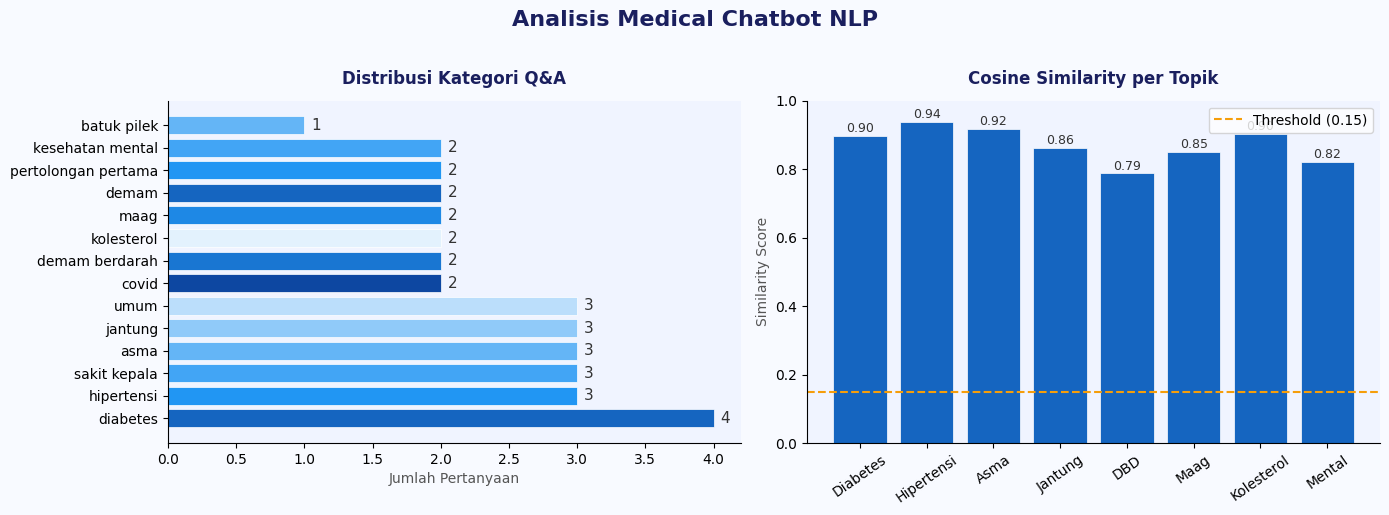

In [ ]:
# ANALISIS DATASET & MODEL
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8faff')
plt.suptitle('Analisis Medical Chatbot NLP', fontsize=16, fontweight='bold', color='#1a1f5e', y=1.02)

# --- Plot 1: Distribusi Kategori ---
category_counts = df['category'].value_counts()
colors = ['#1565c0', '#2196f3', '#42a5f5', '#64b5f6', '#90caf9',
          '#bbdefb', '#0d47a1', '#1976d2', '#e3f2fd', '#1e88e5']
axes[0].barh(category_counts.index, category_counts.values,
             color=colors[:len(category_counts)], edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribusi Kategori Q&A', fontweight='bold', color='#1a1f5e', pad=12)
axes[0].set_xlabel('Jumlah Pertanyaan', color='#555')
axes[0].set_facecolor('#f0f4ff')
axes[0].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(category_counts.values):
    axes[0].text(v + 0.05, i, str(v), va='center', fontsize=11, color='#333')

# --- Plot 2: Similarity Score untuk berbagai pertanyaan test ---
test_cases = [
    ("gejala diabetes", "Diabetes"),
    ("tekanan darah tinggi", "Hipertensi"),
    ("serangan asma inhaler", "Asma"),
    ("serangan jantung", "Jantung"),
    ("demam berdarah trombosit", "DBD"),
    ("sakit maag lambung", "Maag"),
    ("kolesterol ldl", "Kolesterol"),
    ("stres depresi kecemasan", "Mental"),
]

labels, scores = [], []
for query, label in test_cases:
    idx, score = bot._find_best_match(query)
    labels.append(label)
    scores.append(score)

bar_colors = ['#1565c0' if s >= 0.15 else '#ef5350' for s in scores]
bars = axes[1].bar(labels, scores, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].axhline(y=0.15, color='#f59e0b', linestyle='--', linewidth=1.5, label='Threshold (0.15)')
axes[1].set_title('Cosine Similarity per Topik', fontweight='bold', color='#1a1f5e', pad=12)
axes[1].set_ylabel('Similarity Score', color='#555')
axes[1].set_ylim(0, 1)
axes[1].set_facecolor('#f0f4ff')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].legend(fontsize=10)
axes[1].tick_params(axis='x', rotation=35)
for bar, score in zip(bars, scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.2f}', ha='center', fontsize=9, color='#333')

plt.tight_layout()
plt.savefig('medbot_analysis.png', dpi=150, bbox_inches='tight', facecolor='#f8faff')
plt.show()

##  LANGKAH 8: Batch Testing & Evaluasi

batch testing dengan pertanyaan yang bervariasi untuk melihat kemampuan generalisasi chatbot. Ini mirip dengan evaluasi model ML biasa.

In [ ]:
# EVALUASI LENGKAP — termasuk test case baru

test_scenarios = [
    ("sakit kepala", "sakit kepala", "[FIX BUG] Sakit kepala langsung"),
    ("kepala saya pusing", "sakit kepala", "[FIX BUG] Paraphrase sakit kepala"),
    ("migrain berdenyut", "sakit kepala", "[FIX BUG] Migrain"),
    ("gejala diabetes", "diabetes", "Diabetes langsung"),
    ("gula darah saya tinggi", "diabetes", "Paraphrase diabetes"),
    ("kepala saya sakit hipertensi", "hipertensi", "Sakit kepala karena hipertensi"),
    ("cara mengobati sesak napas", "asma", "Pengobatan asma"),
    ("dada sakit menjalar ke lengan", "jantung", "Gejala jantung"),
    ("bintik merah di kulit dan demam", "demam berdarah", "Gejala DBD"),
    ("nyeri ulu hati mual kembung", "maag", "Gejala maag (bukan kepala)"),
    ("sering merasa sedih dan tidak bersemangat", "kesehatan mental", "Gejala depresi"),
    ("halo selamat pagi", "greeting", "Salam"),
    ("topik apa yang tersedia", "capability", "Kemampuan bot"),
    ("ini topik yang tidak ada sama sekali xyzabc", "unknown", "Out-of-scope"),
]

print("=" * 70)
print("LAPORAN EVALUASI MEDBOT v2")
print("=" * 70)

correct = 0

for user_input, expected_cat, description in test_scenarios:
    response = bot.get_response(user_input)
    response_lower = response.lower()
    is_correct = (
        expected_cat in response_lower or
        (expected_cat == 'greeting' and ('halo' in response_lower or 'hai' in response_lower)) or
        (expected_cat == 'capability' and 'topik' in response_lower) or
        (expected_cat == 'unknown' and ('tidak menemukan' in response_lower or 'tidak' in response_lower))
    )

    status = "✅" if is_correct else "❌"
    if is_correct:
        correct += 1

    print(f"\n{status} [{description}]")
    print(f"   Input   : '{user_input}'")
    print(f"   Expected: {expected_cat}")
    first_line = response.split('\n')[0]
    print(f"   Response: {first_line}")

accuracy = correct / len(test_scenarios) * 100
print("\n" + "=" * 70)
print(f"HASIL EVALUASI: {correct}/{len(test_scenarios)} benar ({accuracy:.1f}% akurasi)")
print("=" * 70)

LAPORAN EVALUASI MEDBOT v2

✅ [[FIX BUG] Sakit kepala langsung]
   Input   : 'sakit kepala'
   Expected: sakit kepala
   Response: 

✅ [[FIX BUG] Paraphrase sakit kepala]
   Input   : 'kepala saya pusing'
   Expected: sakit kepala
   Response: 

✅ [[FIX BUG] Migrain]
   Input   : 'migrain berdenyut'
   Expected: sakit kepala
   Response: 

✅ [Diabetes langsung]
   Input   : 'gejala diabetes'
   Expected: diabetes
   Response: 

✅ [Paraphrase diabetes]
   Input   : 'gula darah saya tinggi'
   Expected: diabetes
   Response: 

✅ [Sakit kepala karena hipertensi]
   Input   : 'kepala saya sakit hipertensi'
   Expected: hipertensi
   Response: 

✅ [Pengobatan asma]
   Input   : 'cara mengobati sesak napas'
   Expected: asma
   Response: 

✅ [Gejala jantung]
   Input   : 'dada sakit menjalar ke lengan'
   Expected: jantung
   Response: 

❌ [Gejala DBD]
   Input   : 'bintik merah di kulit dan demam'
   Expected: demam berdarah
   Response: 

✅ [Gejala maag (bukan kepala)]
   Input   : 'nyeri 